In [1]:
import pandas as pd
# Load dataset
df = pd.read_excel("breast cancer data.xlsx", header=1)

# Remove unnecessary columns
if 'id' in df.columns:
    df.drop(columns=['id'], inplace=True)

if 'Unnamed: 32' in df.columns:
    df.drop(columns=['Unnamed: 32'], inplace=True)

# Fill missing values with mean
df.fillna(df.mean(numeric_only=True), inplace=True)
from sklearn.preprocessing import LabelEncoder

# Encode diagnosis into numbers
le = LabelEncoder()
df['diagnosis_num'] = le.fit_transform(df['diagnosis'])

# Update X and y
X = df.drop(columns=['diagnosis', 'diagnosis_num'])
y = df['diagnosis_num']

# Define X and y
X = df.drop(columns=['area_mean', 'diagnosis', 'diagnosis_num'])
y = df['area_mean']



In [2]:
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1
X = X[~((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)]
y = y[X.index]


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [4]:
from sklearn.linear_model import LinearRegression

# Train the Linear Regression model and predict the test values
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [5]:
from sklearn.preprocessing import PolynomialFeatures

# Transform the data into polynomial features and train the model
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)
y_pred_poly = lr_poly.predict(X_test_poly)

In [6]:
from sklearn.linear_model import Ridge

# Train the Ridge Regression model and predict the test values
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

In [20]:
from sklearn.linear_model import Lasso

# Train the Lasso Regression model and predict the test values
lasso = Lasso(alpha=0.01,max_iter=10000)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

In [21]:
from sklearn.linear_model import ElasticNet
# Train the Elastic Net Regression model and predict the test values
elastic = ElasticNet(alpha=0.01, l1_ratio=0.5,max_iter=10000)
elastic.fit(X_train, y_train)
y_pred_elastic = elastic.predict(X_test)

In [22]:
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Compare all regression models using MSE and R-squared
results = pd.DataFrame({
    'Model': ['Linear', 'Polynomial', 'Ridge', 'Lasso', 'ElasticNet'],
    'MSE': [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_poly),
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_lasso),
        mean_squared_error(y_test, y_pred_elastic)
    ],
    'R2 Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_poly),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_elastic)
    ]})

print(results)

        Model         MSE  R2 Score
0      Linear  130.068552  0.997706
1  Polynomial   15.955561  0.999719
2       Ridge  106.523448  0.998122
3       Lasso  120.027540  0.997883
4  ElasticNet  108.203149  0.998092


In [23]:
# Select the model with the highest R-squared value
best_model = results.loc[results['R2 Score'].idxmax()]
print(best_model)

Model       Polynomial
MSE          15.955561
R2 Score      0.999719
Name: 1, dtype: object


In [24]:
# Print the intercept and coefficients of the Linear Regression model
a = lr.intercept_
b = lr.coef_

print(a)
print(b)

-206.90004411609232
[ 1.15917439e+02  6.14527875e-01 -3.29075216e+00 -3.34519164e+02
 -8.41853170e+01 -9.63626500e+01  4.57154714e+02 -4.78549443e+01
  5.08975975e+02  1.93456249e+02  3.57157054e+00  5.01674623e+00
 -2.40617119e+00  2.48637470e+02  3.49698461e+02  2.57796657e+02
 -7.55933374e+02 -6.00628106e+02 -1.09321329e+03 -6.34995324e+01
 -6.69103546e-01 -5.93603844e-01  6.71474135e-01  2.39440166e+02
 -1.77422552e+01  2.58574828e+00 -7.84593579e+01  8.12740142e+01
  4.35630318e+01]


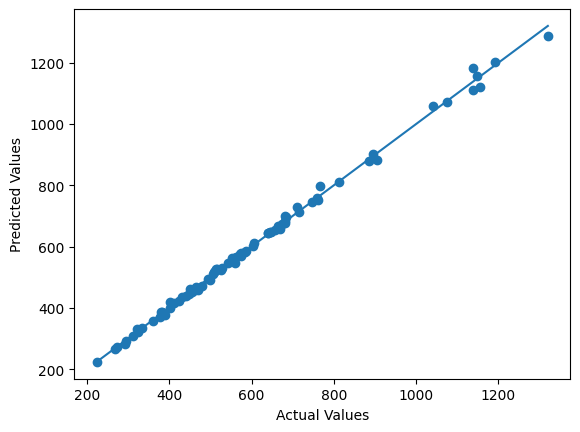

In [12]:
import matplotlib.pyplot as plt
# Plot the actual values against the predicted values
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)])
plt.show()

In [13]:
#Start cluster
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [14]:
#cluster
# Load the breast cancer dataset and select two features for clustering
dataset = pd.read_excel("breast cancer data.xlsx", header=1)
X = dataset[['area_mean', 'radius_mean']].values
print(X)

[[1001.     17.99]
 [1326.     20.57]
 [1203.     19.69]
 ...
 [ 858.1    16.6 ]
 [1265.     20.6 ]
 [ 181.      7.76]]


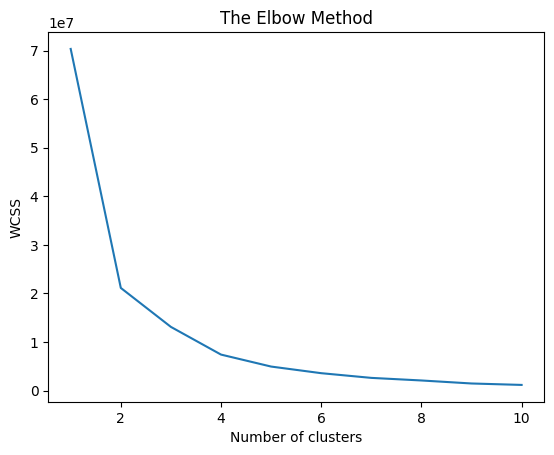

In [15]:
#cluster
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [16]:
#cluster
# Apply the K-Means model using the selected number of clusters
kmeans = KMeans(n_clusters = 3, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)
print(y_kmeans)

[2 0 0 1 0 1 2 1 1 1 2 2 0 2 1 2 2 2 0 1 1 1 2 0 2 2 2 0 2 2 0 1 2 0 2 2 2
 1 2 1 1 1 0 1 1 0 1 1 1 1 1 1 1 2 2 1 0 2 1 1 1 1 2 1 1 2 1 1 1 1 0 1 2 1
 1 2 1 2 0 1 1 1 0 0 1 0 2 0 1 2 2 2 1 1 2 0 1 1 1 2 1 1 1 1 1 1 1 1 0 1 1
 1 2 1 1 1 1 2 2 2 1 0 0 2 1 1 1 0 2 0 1 2 2 2 0 1 1 1 2 1 1 2 1 1 1 1 1 2
 2 1 1 1 1 1 1 1 2 2 1 1 1 0 0 1 0 2 1 2 2 2 1 1 2 1 1 1 1 2 1 1 0 0 2 1 2
 1 2 1 1 1 2 1 1 1 2 1 1 2 0 2 1 2 0 2 1 2 1 2 1 2 0 1 0 2 2 1 1 1 0 0 1 1
 1 2 1 2 1 2 1 1 2 1 1 0 1 2 0 0 2 2 1 1 1 1 0 1 1 1 1 1 0 1 0 2 0 2 0 2 2
 2 0 2 2 2 2 0 1 1 1 1 2 1 0 1 2 1 1 0 1 1 0 1 0 2 1 1 1 1 1 1 2 2 1 1 1 1
 1 1 2 1 0 1 0 1 1 1 1 1 1 1 1 2 1 1 1 1 1 2 1 1 1 0 1 0 1 1 2 1 2 2 2 1 1
 1 1 2 1 0 1 0 2 1 1 0 1 1 1 2 1 1 1 2 0 2 1 1 1 1 1 1 1 1 1 2 1 0 0 1 0 0
 2 2 0 0 1 2 1 1 1 1 1 1 1 1 1 2 1 1 1 0 1 1 2 0 1 2 1 1 1 1 2 1 1 1 1 1 2
 1 2 1 1 1 1 2 2 1 1 2 1 1 1 2 1 1 1 1 1 1 1 1 2 1 0 0 2 2 1 2 1 2 1 2 1 1
 2 1 2 2 2 0 1 0 1 2 1 1 1 1 1 1 2 0 2 1 1 1 1 1 2 1 1 1 2 1 1 1 2 2 1 2 1
 2 1 1 2 1 2 0 1 2 1 2 2 

In [17]:
from sklearn.cluster import AgglomerativeClustering

# Train the hierarchical clustering model
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')

y_hc = hc.fit_predict(X)

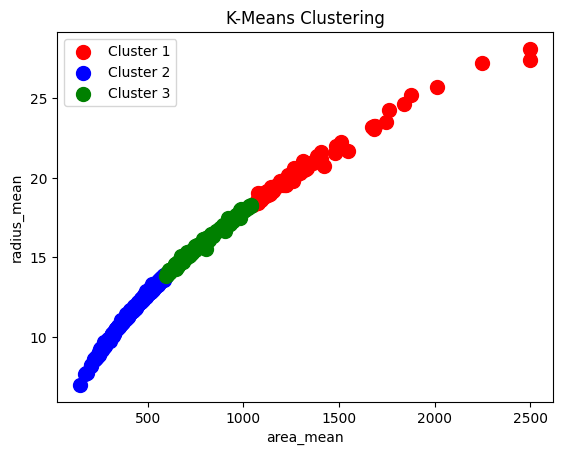

In [28]:
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s=100, c='red', label='Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s=100, c='blue', label='Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s=100, c='green', label='Cluster 3')

plt.title('K-Means Clustering')
plt.xlabel('area_mean')
plt.ylabel('radius_mean')
plt.legend()
plt.show()

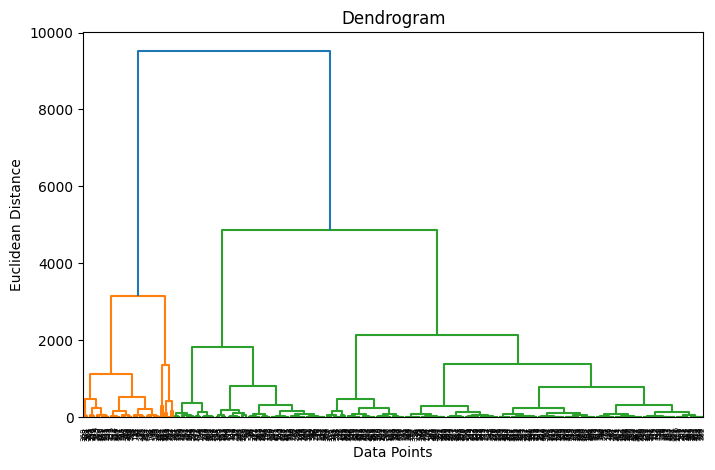

In [29]:
#Hierarchical Clustering is also applied to group the dataset using a tree-based structure.
#The dendrogram helps determine the optimal number of clusters, and the results are compared with K-Means clustering.
#Cluster, Hierarchical Clustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Create dendrogram
linked = linkage(X, method='ward')

plt.figure(figsize=(8,5))
dendrogram(linked)
plt.title('Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distance')
plt.show()